In [62]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as py
import pandas as pd

In [63]:
df = pd.read_csv("C:/Users/ADMIN/Desktop/Lboro/adv programming & DV/coursework/bank-full - Copy.csv", sep= ";")

In [64]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [66]:
df.shape

(45211, 17)

In [67]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [68]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [71]:
ndf = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing','loan', 'contact', 'day', 'month', 'campaign', 'pdays','previous', 'poutcome', 'y']
df = df.drop([c for c in df.columns if c not in ndf], axis = 1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [72]:
df['y'] = df['y'].map({'yes':1,'no':0}) 

Text(0.5, 1.0, 'subscription distribution')

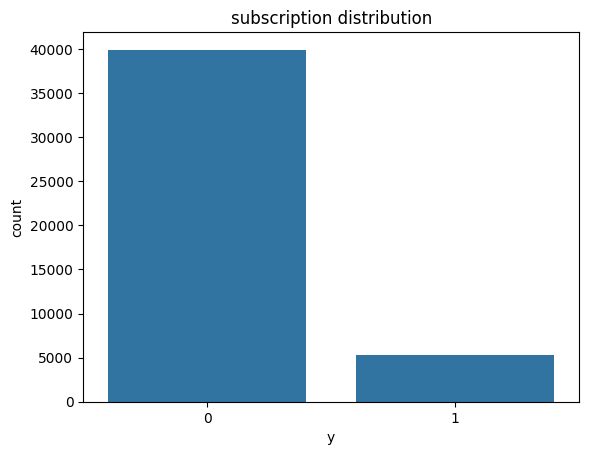

In [73]:
sns.countplot(x='y', data = df)
py.title("subscription distribution")

In [74]:
df['y'].value_counts(normalize=True)

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Previious VS Current campaign customers')

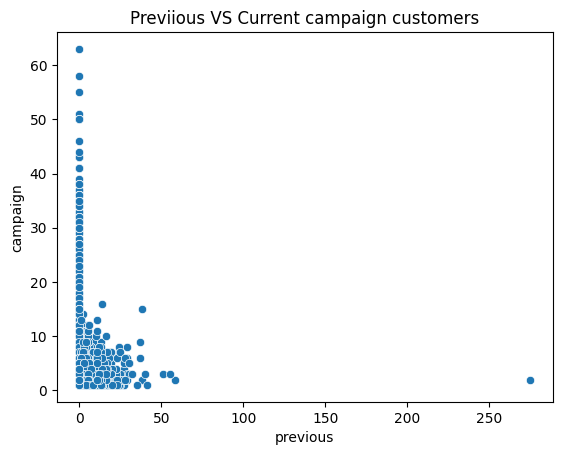

In [75]:
sns.scatterplot(x= 'previous', y= 'campaign', data = df)
py.title('Previious VS Current campaign customers')

In [76]:
df[df['previous'] > 100]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
29182,40,management,married,tertiary,no,543,yes,no,cellular,2,feb,2,262,275,other,0


In [77]:
df['previous'] = df['previous'].clip(upper=60)

Text(0.5, 1.0, 'Previious VS Current campaign customers')

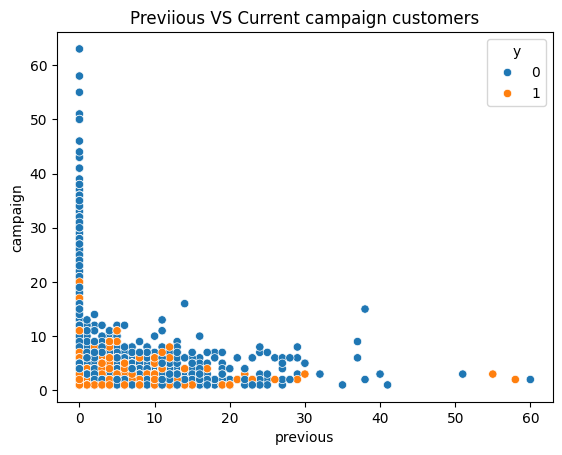

In [78]:
sns.scatterplot(x= 'previous', y= 'campaign', hue = 'y', data = df)
py.title('Previious VS Current campaign customers')

Text(0.5, 1.0, 'Age and Subscription')

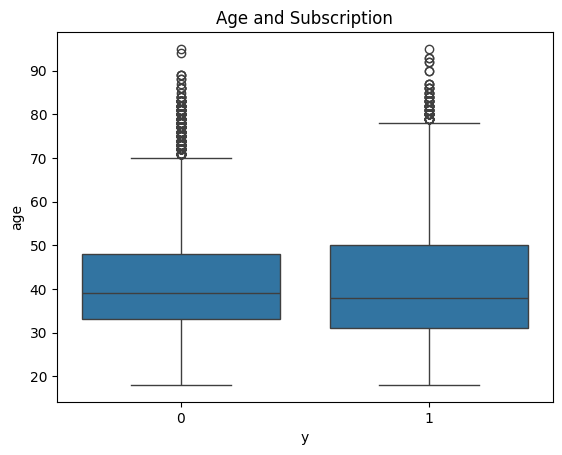

In [79]:
sns.boxplot(x = 'y', y = 'age', data =df)
py.title('Age and Subscription')

Text(0.5, 1.0, 'Age and Balance')

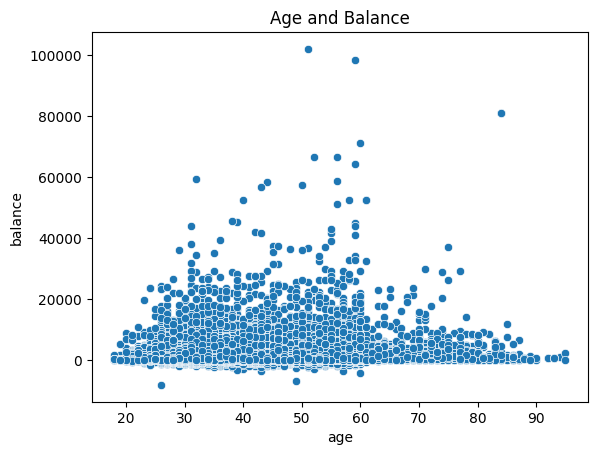

In [80]:
sns.scatterplot(x= 'age', y= 'balance', data = df)
py.title('Age and Balance')

Text(0.5, 1.0, 'Balance Distribution by Subscription')

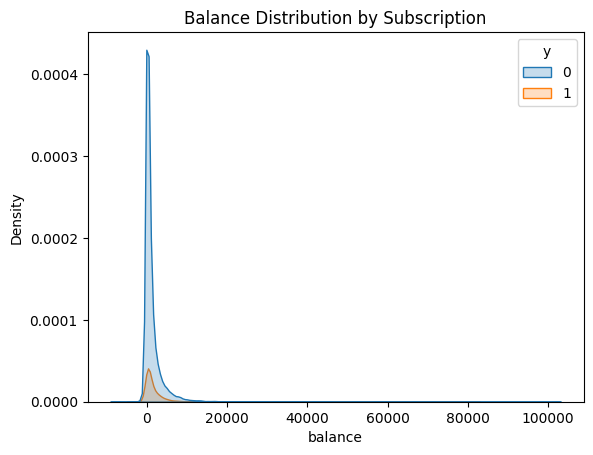

In [81]:
sns.kdeplot(data=df, x='balance', hue='y', fill=True)
py.title("Balance Distribution by Subscription")

Text(0.5, 1.0, 'Job and Balance')

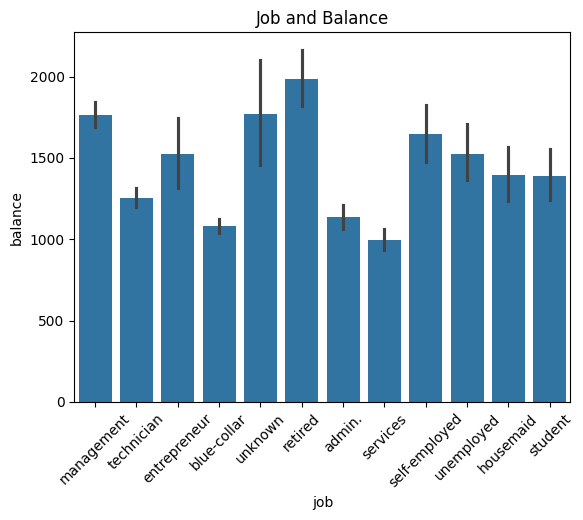

In [82]:
sns.barplot(x = 'job', y = 'balance', data =df)
py.xticks(rotation=45)
py.title('Job and Balance')

<Axes: xlabel='job'>

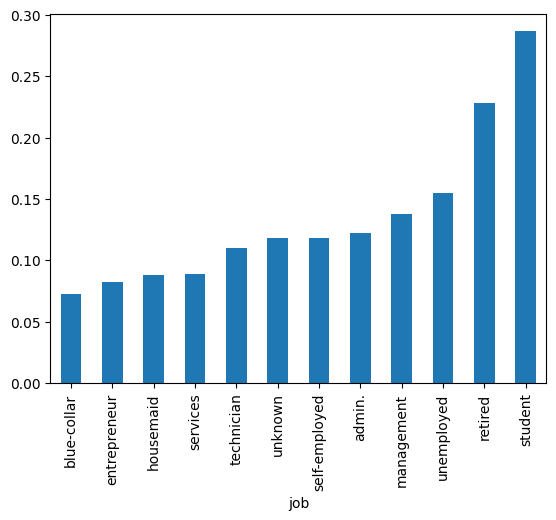

In [83]:
df.groupby('job')['y'].mean().sort_values().plot(kind='bar')

Text(0.5, 1.0, 'Balance and Subscription')

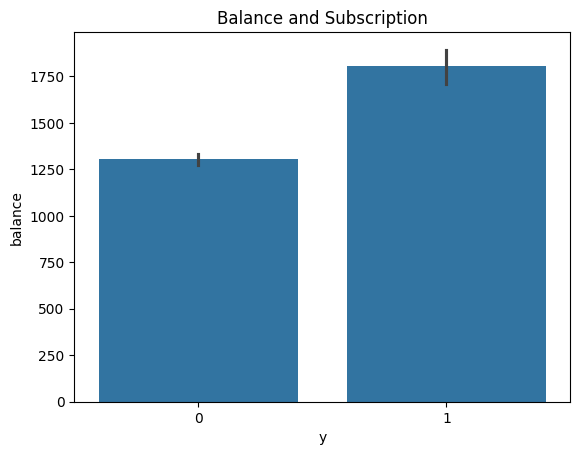

In [84]:
sns.barplot(x = 'y', y = 'balance', data =df)
py.title('Balance and Subscription')

Text(0.5, 1.0, 'Days Since Last Contact vs Previous Contacts')

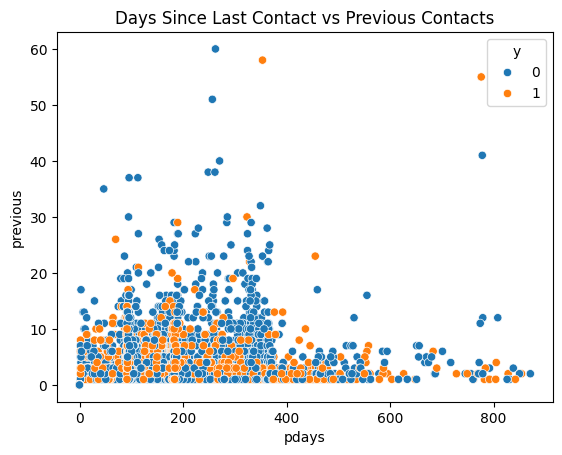

In [85]:
sns.scatterplot(x='pdays', y='previous', hue= 'y', data=df)
py.title("Days Since Last Contact vs Previous Contacts")

Text(0.5, 1.0, 'Campaign Contacts vs Subscription')

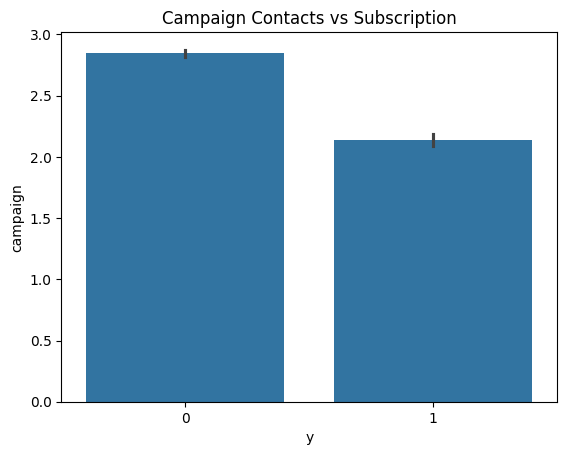

In [86]:
sns.barplot(x='y', y='campaign', data=df)
py.title("Campaign Contacts vs Subscription")

<Axes: xlabel='poutcome', ylabel='count'>

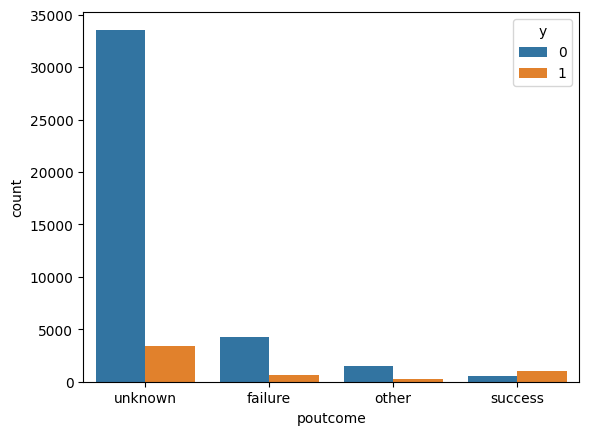

In [87]:
sns.countplot(x='poutcome', hue='y', data=df)

<Axes: xlabel='marital', ylabel='count'>

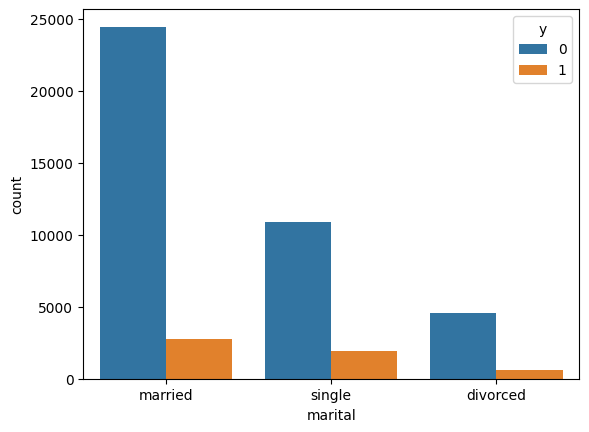

In [88]:
sns.countplot(x='marital', hue='y', data=df)

<Axes: xlabel='housing', ylabel='count'>

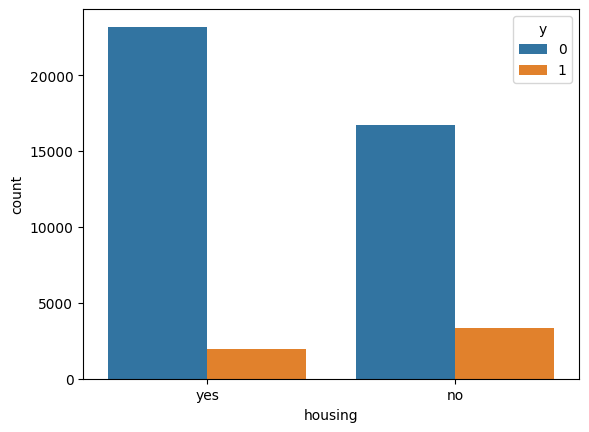

In [89]:

sns.countplot(x='housing', hue='y', data=df)

In [90]:
bncols = ['default', 'housing', 'loan']
for col in bncols:
    df[col] = df[col].map({'yes':1,'no':0})

In [91]:
df = pd.get_dummies(df, columns=['job','marital','education','contact','month','poutcome'], drop_first=True)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   default              45211 non-null  int64
 2   balance              45211 non-null  int64
 3   housing              45211 non-null  int64
 4   loan                 45211 non-null  int64
 5   day                  45211 non-null  int64
 6   campaign             45211 non-null  int64
 7   pdays                45211 non-null  int64
 8   previous             45211 non-null  int64
 9   y                    45211 non-null  int64
 10  job_blue-collar      45211 non-null  bool 
 11  job_entrepreneur     45211 non-null  bool 
 12  job_housemaid        45211 non-null  bool 
 13  job_management       45211 non-null  bool 
 14  job_retired          45211 non-null  bool 
 15  job_self-employed    45211 non-null  bool 
 16  job_services         4

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score

In [94]:
X = df.drop('y', axis=1)
y = df['y']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [96]:
logmod = LogisticRegression(class_weight='balanced')

In [97]:
logmod.fit(X_train, y_train)

C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
predLR = logmod.predict(X_test)

In [99]:
lr_probs = logmod.predict_proba(X_test)[:,1]

In [100]:
accuracy_score(y_test, predLR)

0.6540970916731174

In [101]:
precision_score(y_test, predLR)

0.20858369098712445

In [102]:
recall_score(y_test, predLR)

0.6681943171402384

Text(0.5, 1.0, 'Confusion Matrix')

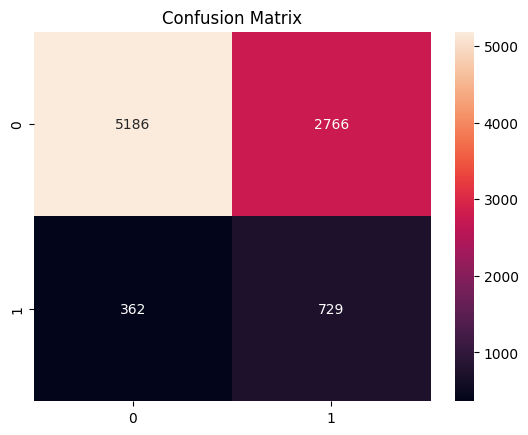

In [ ]:
cm = confusion_matrix(y_test, predLR)
sns.heatmap(cm, annot = True, fmt = 'd')
py.title('LR Confusion Matrix')

In [104]:
from sklearn.naive_bayes import GaussianNB

In [105]:
nb = GaussianNB( )
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [106]:
predNB = nb.predict(X_test)
accuracy_score(y_test, predNB)

0.8437465442883999

In [107]:
nb_probs = nb.predict_proba(X_test)[:,1]

In [108]:
from sklearn.tree import DecisionTreeClassifier

In [109]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state = 42)

In [110]:
dt = dt.fit(X_train,y_train)

In [111]:
predDT = dt.predict(X_test)
accuracy_score(y_test, predDT)

0.8361163330753069

In [112]:
dt_probs = dt.predict_proba(X_test)[:,1]

Text(0.5, 1.0, 'Confusion Matrix')

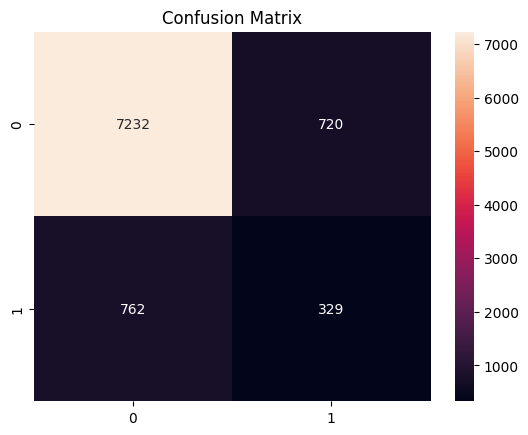

In [113]:
cm = confusion_matrix(y_test, predDT)
sns.heatmap(cm, annot = True, fmt = 'd')
py.title('Confusion Matrix')

In [114]:
from sklearn.ensemble import RandomForestClassifier

In [115]:
rf = RandomForestClassifier(n_estimators = 300,class_weight='balanced',random_state = 42)

In [116]:
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
predRF = rf.predict(X_test)
accuracy_score(y_test, predRF)

0.8937299568727193

In [118]:
rf_probs = rf.predict_proba(X_test)[:,1]

In [1]:
cm = confusion_matrix(y_test, predRF)
sns.heatmap(cm, annot = True, fmt = 'd')
py.title('RF Confusion Matrix')

NameError: name 'confusion_matrix' is not defined

In [120]:
from sklearn.metrics import roc_auc_score, roc_curve

In [121]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
nb_auc = roc_auc_score(y_test, nb_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

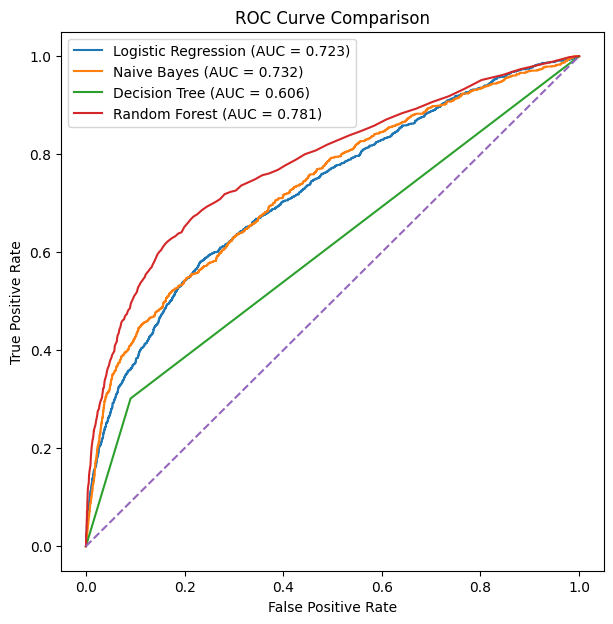

In [122]:
py.figure(figsize=(7,7))

py.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
py.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.3f})')
py.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.3f})')
py.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')

py.plot([0,1],[0,1],'--')  # random guessing line

py.xlabel("False Positive Rate")
py.ylabel("True Positive Rate")
py.title("ROC Curve Comparison")
py.legend()